# 03 - Analyse des contenus

## Objectif

Cette analyse étudie la composition du catalogue et son évolution dans le temps.

Nous allons notamment comparer les films et les séries et observer l'évolution du nombre de contenus selon leur année de sortie.


## 1. Importation des bibliothèques

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")


## 2. Chargement des données

In [2]:
df = pd.read_csv("../data/processed/netflix_titles_clean.csv")

print(f"Dataset : {df.shape[0]} contenus et {df.shape[1]} variables")


Dataset : 8807 contenus et 12 variables


## 3. Films vs séries

In [3]:
content_type = df["type"].value_counts()

content_type


type
Movie      6131
TV Show    2676
Name: count, dtype: int64

In [4]:
content_percentage = (
    df["type"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

content_percentage


type
Movie      69.62
TV Show    30.38
Name: proportion, dtype: float64

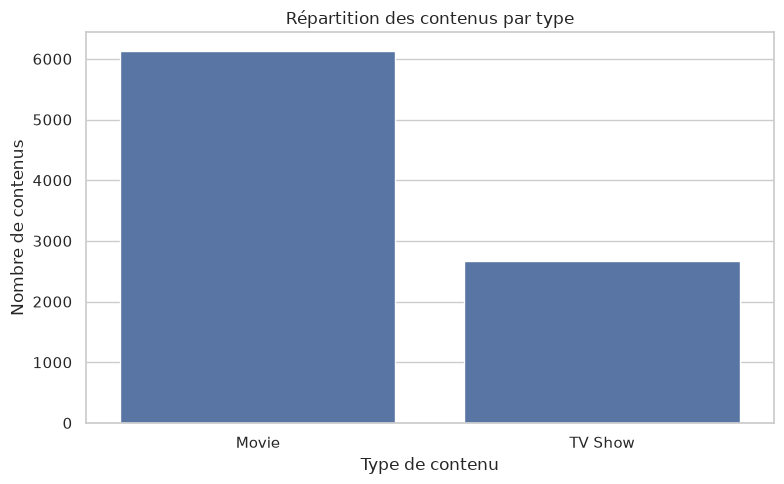

In [5]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="type"
)

plt.title("Répartition des contenus par type")
plt.xlabel("Type de contenu")
plt.ylabel("Nombre de contenus")
plt.tight_layout()
plt.show()


### Observation

Le catalogue est composé de deux types de contenus : les films et les séries.

La comparaison de leurs proportions permet de déterminer quel format est majoritaire dans le dataset.


## 4. Évolution des contenus selon l'année de sortie

In [6]:
content_by_year = (
    df["release_year"]
    .value_counts()
    .sort_index()
)

content_by_year.tail(20)


release_year
2002      51
2003      61
2004      64
2005      80
2006      96
2007      88
2008     136
2009     152
2010     194
2011     185
2012     237
2013     288
2014     352
2015     560
2016     902
2017    1032
2018    1147
2019    1030
2020     953
2021     592
Name: count, dtype: int64

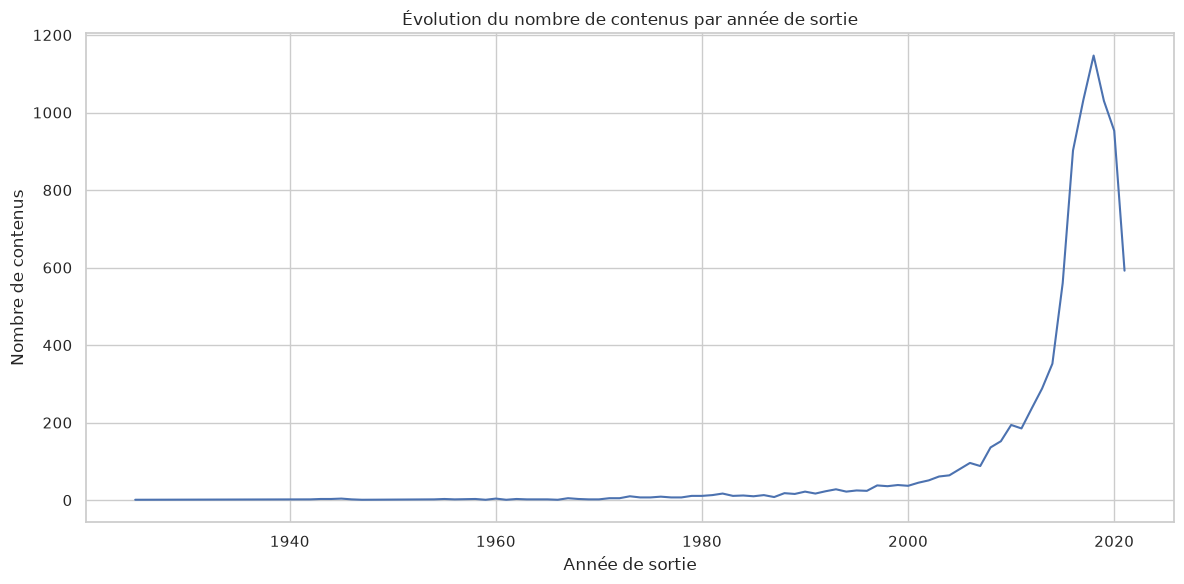

In [7]:
plt.figure(figsize=(12, 6))

plt.plot(
    content_by_year.index,
    content_by_year.values
)

plt.title("Évolution du nombre de contenus par année de sortie")
plt.xlabel("Année de sortie")
plt.ylabel("Nombre de contenus")
plt.tight_layout()
plt.show()


## 5. Évolution par type de contenu

In [8]:
content_type_by_year = (
    df.groupby(["release_year", "type"])
    .size()
    .unstack(fill_value=0)
)

content_type_by_year.tail(20)


type,Movie,TV Show
release_year,,
2002,44,7
2003,51,10
2004,55,9
2005,67,13
2006,82,14
2007,74,14
2008,113,23
2009,118,34
2010,154,40


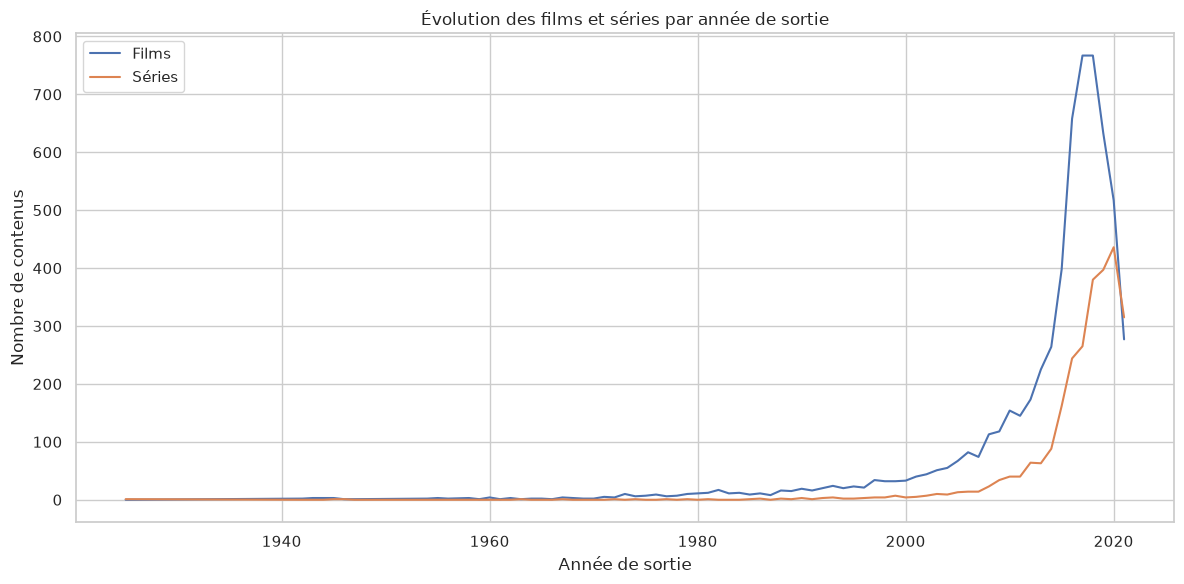

In [9]:
plt.figure(figsize=(12, 6))

plt.plot(
    content_type_by_year.index,
    content_type_by_year["Movie"],
    label="Films"
)

plt.plot(
    content_type_by_year.index,
    content_type_by_year["TV Show"],
    label="Séries"
)

plt.title("Évolution des films et séries par année de sortie")
plt.xlabel("Année de sortie")
plt.ylabel("Nombre de contenus")
plt.legend()
plt.tight_layout()
plt.show()


## 6. Années les plus représentées

In [10]:
top_years = (
    df["release_year"]
    .value_counts()
    .head(10)
)

top_years


release_year
2018    1147
2017    1032
2019    1030
2020     953
2016     902
2021     592
2015     560
2014     352
2013     288
2012     237
Name: count, dtype: int64

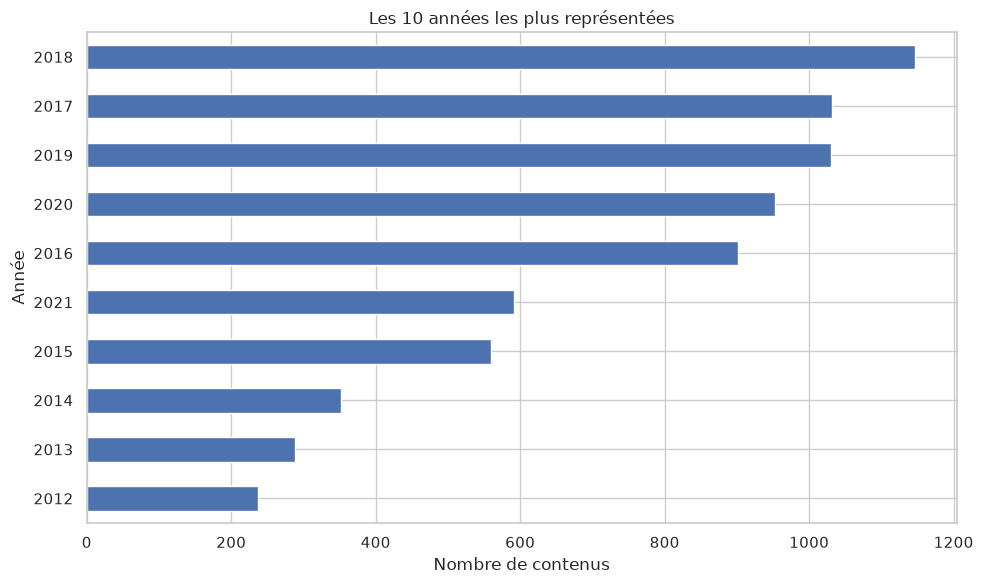

In [11]:
plt.figure(figsize=(10, 6))

top_years.sort_values().plot(kind="barh")

plt.title("Les 10 années les plus représentées")
plt.xlabel("Nombre de contenus")
plt.ylabel("Année")
plt.tight_layout()
plt.show()


## 7. Répartition des sorties récentes

In [12]:
recent_content = df[df["release_year"] >= 2015]

recent_by_type = recent_content["type"].value_counts()

recent_by_type


type
Movie      4017
TV Show    2199
Name: count, dtype: int64

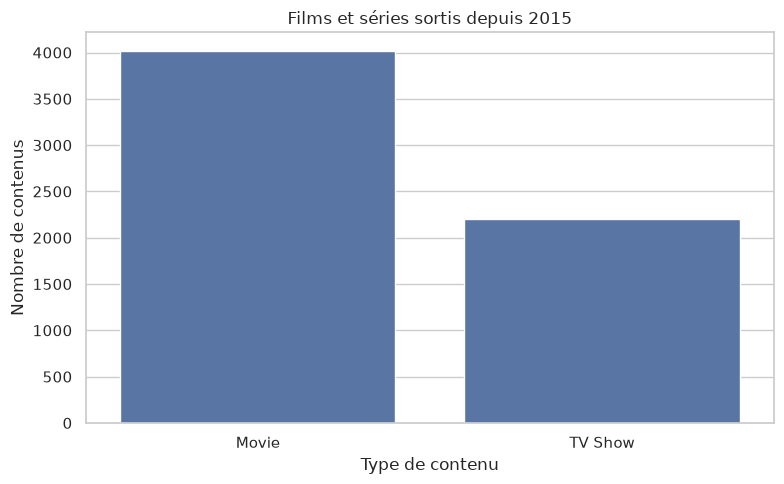

In [13]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=recent_content,
    x="type"
)

plt.title("Films et séries sortis depuis 2015")
plt.xlabel("Type de contenu")
plt.ylabel("Nombre de contenus")
plt.tight_layout()
plt.show()


## 8. Conclusion

Cette analyse permet d'identifier la composition du catalogue et les principales périodes de production représentées dans le dataset.

Les résultats montrent la place respective des films et des séries ainsi que les années durant lesquelles le catalogue contient le plus de sorties.

Les prochaines analyses permettront d'étudier plus précisément les catégories, les pays d'origine et les classifications des contenus.
